# 2.2 Spatial Weights: Building and Understanding

**Part:** 2 — Spatial Autocorrelation (Chapter 2.2 of 6)

**Dataset:** `diabetes_northeast.shp` (217 counties); a synthetic 8×8 lattice (`spatialstats.datasets.load_lattice`)

**Focus:** Building and comparing spatial weights matrices — contiguity, distance, kernel, and graph-based definitions

**Library:** `spatialstats.weights` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Anatomy of a Weights Matrix](#3.-Anatomy-of-a-Weights-Matrix)
4.. [Contiguity Weights: Queen and Rook](#4.-Contiguity-Weights:-Queen-and-Rook)
   - 4.1 [Same idea, different graphs: lattice vs. irregular counties](#4.1-Same-idea,-different-graphs:-lattice-vs.-irregular-counties)
5.. [Distance-based Weights: KNN, DistanceBand, Kernel](#5.-Distance-based-Weights:-KNN,-DistanceBand,-Kernel)
   - 5.1 [K-nearest neighbours: an asymmetric relation](#5.1-K-nearest-neighbours:-an-asymmetric-relation)
   - 5.2 [Distance band: the smallest island-free threshold](#5.2-Distance-band:-the-smallest-island-free-threshold)
   - 5.3 [Kernel weights](#5.3-Kernel-weights)
   - 5.4 [Coordinates for distance-based weights: representative point vs. centroid](#5.4-Coordinates-for-distance-based-weights:-representative-point-vs.-centroid)
6.. [Graph-based Weights: Delaunay, Gabriel, Relative Neighbourhood](#6.-Graph-based-Weights:-Delaunay,-Gabriel,-Relative-Neighbourhood)
7.. [Higher-order Neighbours and Correlograms](#7.-Higher-order-Neighbours-and-Correlograms)
8.. [Transformations](#8.-Transformations)
9.. [Islands and Disconnected Components](#9.-Islands-and-Disconnected-Components)
10.. [Spatial Lag by Hand](#10.-Spatial-Lag-by-Hand)
11.. [Interoperability with libpysal](#11.-Interoperability-with-libpysal)
12.. [A Sensitivity Preview: Six Weight Definitions, One Variable](#12.-A-Sensitivity-Preview:-Six-Weight-Definitions,-One-Variable)
13.. [Summary and Conclusions](#13.-Summary-and-Conclusions)
14.. [Resources](#14.-Resources)

***
## 1. Overview

Every statistic in this Part — Moran's I, LISA, the hot-spot tests of Part 4, the spatial regression models of
Part 3 — starts from the same object: a **spatial weights matrix** $W$, an $n \times n$ matrix whose entry
$w_{ij}$ encodes how much region $j$ counts as a "neighbour" of region $i$. Nothing about $W$ is handed to us by
the data; every choice below (which counties touch, how many nearest neighbours, what distance counts as
"close") is an analyst decision, and Chapter 2.6 shows that the choice is not innocuous.

| Step | What we do |
|------|------------|
| Anatomy | Inspect the `W` object's attributes: `neighbors`, `weights`, `sparse`, `cardinalities`, `islands` |
| Contiguity | `Queen` (shared edge or vertex) vs `Rook` (shared edge only) |
| Distance | `KNN`, `DistanceBand`, `Kernel` — and why `KNN` is not symmetric |
| Graph | `Delaunay`, `Gabriel`, `RelativeNeighborhood` — a strictly nested family |
| Correlograms | `higher_order(w, k)` for second-, third-, ... order neighbours |
| Transforms | Row-standardised vs. binary vs. variance-stabilising weights |
| Islands | What a disconnected component means for every downstream statistic |
| Validation | Hand-compute a spatial lag on the 8×8 lattice and check it against `W.lag` |
| Preview | Six weight definitions, one variable, six different Moran's I values |

By the end, Chapter 2.3 can take any of these `W` objects and turn it into a Moran scatterplot.

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import (
    Queen, Rook, KNN, DistanceBand, Kernel, Delaunay, Gabriel, RelativeNeighborhood, higher_order,
)
from spatialstats.esda import Moran
from spatialstats.datasets import load_lattice

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
lattice, zcol = load_lattice(n=8, seed=0)
print(f"spatialstats  : version {spatialstats.__version__}")
print(f"counties      : {counties.shape[0]} rows")
print(f"lattice       : {lattice.shape[0]} cells, attribute column {zcol!r}")

spatialstats  : version 0.2.0
counties      : 217 rows
lattice       : 64 cells, attribute column 'z'


***
## 3. Anatomy of a Weights Matrix

`spatialstats.weights.W` wraps a **sparse** neighbour structure with a small, consistent API regardless of how
it was built.

In [2]:
w = Queen(counties)
print(w)
print()
print(w.summary())

W(n=217, transform='row', nnz=1126, islands=1)

Spatial Weights (W)
  Observations        217
  Transform           row
  Min neighbors       0
  Mean neighbors      5.189
  Max neighbors       10
  Islands             1
  Components          2
  Nonzero weights     1126


- **`.neighbors`** and **`.weights`** are dictionaries keyed by the original id (here, the GeoDataFrame index):
  `neighbors[i]` lists the ids of `i`'s neighbours, `weights[i]` the corresponding weights.
- **`.id_order`** fixes the row/column order of the matrix form; **`.sparse`** is that matrix as a SciPy CSR
  array — everything downstream (`Moran`, `Moran_Local`, regression) works from this sparse form for speed.
- **`.cardinalities()`** — neighbour counts per area; **`.islands()`** — ids with zero neighbours;
  **`.n_components()`** — connected components of the (undirected) neighbour graph; **`.is_symmetric()`** —
  whether $w_{ij} = w_{ji}$ for all pairs (true for contiguity and graph weights, generally false for `KNN`).

In [3]:
cards = w.cardinalities()
print(f"cardinalities: min={cards.min()}, mean={cards.mean():.3f}, max={cards.max()}")
print(f"islands: {w.islands()}  (n_components={w.n_components()})")
print(f"is_symmetric: {w.is_symmetric()}")
print(f"id_order[:5]: {w.id_order[:5]}")
print(f"neighbors[0]: {w.neighbors[0]}")
print(f"weights[0]:   {w.weights[0]}")

cardinalities: min=0, mean=5.189, max=10
islands: [33]  (n_components=2)
is_symmetric: False
id_order[:5]: [0, 1, 2, 3, 4]
neighbors[0]: [2, 4, 82, 108, 128]
weights[0]:   [0.2, 0.2, 0.2, 0.2, 0.2]


Note that `weights[0]` already shows **row-standardised** values (each entry $1/5$ for 5 neighbours) — `Queen`
defaults to `transform="row"`. Section 8 covers what the transforms mean and why row-standardisation is the
default.

***
## 4. Contiguity Weights: Queen and Rook

**Queen** contiguity links regions that share any part of their boundary — an edge *or* a single vertex.
**Rook** contiguity requires a shared edge (a positive-length border); vertex-only ("corner") touches do not
count.

In [4]:
wq = Queen(counties)
wr = Rook(counties)
same = all(set(wq.neighbors[i]) == set(wr.neighbors[i]) for i in wq.id_order)
print(f"Queen : mean neighbours {wq.cardinalities().mean():.3f}, nonzero links {wq.sparse.nnz}")
print(f"Rook  : mean neighbours {wr.cardinalities().mean():.3f}, nonzero links {wr.sparse.nnz}")
print(f"identical neighbour sets on every county? {same}")

diff_counties = [i for i in wq.id_order if set(wq.neighbors[i]) != set(wr.neighbors[i])]
print(f"counties where Queen and Rook disagree: {len(diff_counties)} of {len(wq.id_order)}")

Queen : mean neighbours 5.189, nonzero links 1126
Rook  : mean neighbours 5.152, nonzero links 1118
identical neighbour sets on every county? False
counties where Queen and Rook disagree: 8 of 217


### 4.1 Same idea, different graphs: lattice vs. irregular counties

On the Northeast counties, Queen and Rook are nearly identical (a handful of corner-only touches). On a
**regular square lattice**, the difference is structural: every interior cell has 4 edge-neighbours under Rook
but 8 neighbours (edges *and* diagonals) under Queen — exactly double.

Lattice (8x8): Queen mean neighbours = 6.562  (interior cells get 8: N,S,E,W + 4 diagonals)
Lattice (8x8): Rook  mean neighbours = 3.500  (interior cells get 4: N,S,E,W only)


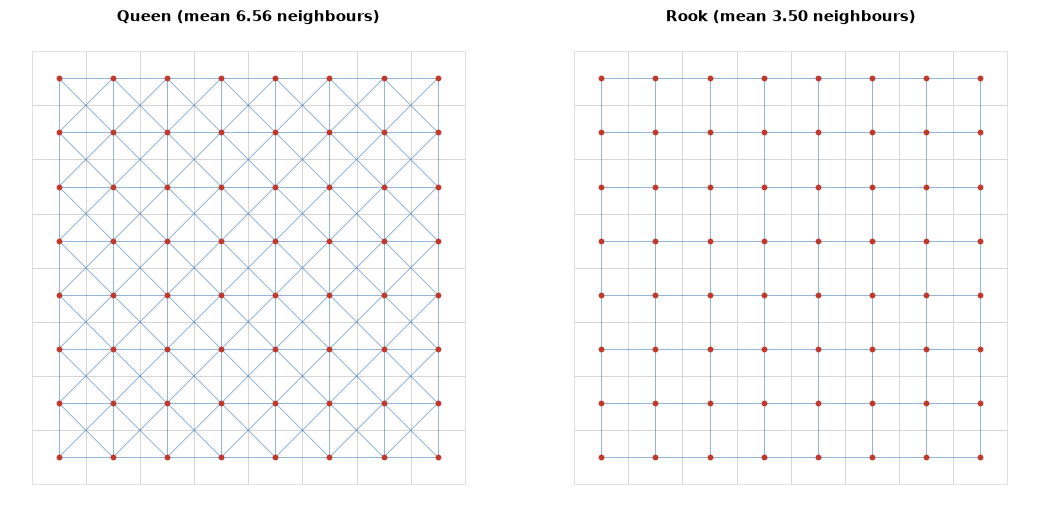

In [5]:
wq_lat = Queen(lattice)
wr_lat = Rook(lattice)
print(f"Lattice (8x8): Queen mean neighbours = {wq_lat.cardinalities().mean():.3f}  "
      f"(interior cells get 8: N,S,E,W + 4 diagonals)")
print(f"Lattice (8x8): Rook  mean neighbours = {wr_lat.cardinalities().mean():.3f}  "
      f"(interior cells get 4: N,S,E,W only)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, w, title in [(axes[0], wq_lat, "Queen"), (axes[1], wr_lat, "Rook")]:
    lattice.plot(ax=ax, facecolor="none", edgecolor="lightgrey", linewidth=0.5)
    cx = lattice.geometry.centroid.x.to_numpy()
    cy = lattice.geometry.centroid.y.to_numpy()
    for i in w.id_order:
        for j in w.neighbors[i]:
            if j > i:
                ax.plot([cx[i], cx[j]], [cy[i], cy[j]], color=C["blue"], lw=0.6, alpha=0.6)
    ax.scatter(cx, cy, s=10, color=C["red"], zorder=3)
    ax.set_title(f"{title} (mean {w.cardinalities().mean():.2f} neighbours)")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

The gap between "similar on irregular counties, very different on a regular grid" is not a coincidence: on a
lattice, diagonal *vertex* touches are as numerous and as regular as edge touches, so including them (Queen)
doubles the neighbour count in a structured way. On irregular county polygons, corner-only touches are rare
geometric accidents, so the two definitions mostly agree.

***
## 5. Distance-based Weights: KNN, DistanceBand, Kernel

### 5.1 K-nearest neighbours: an asymmetric relation

`KNN(k)` links each region to its `k` nearest neighbours by centroid distance. Because "is one of my $k$
nearest" is not a symmetric relation (county $A$ can be among $B$'s 4 nearest without $B$ being among $A$'s 4
nearest, if $A$ sits in a locally sparse area), the resulting `W` is **not symmetric**.

In [6]:
for k in (4, 6, 8):
    wk = KNN(counties, k=k)
    directed_pairs = sum(len(v) for v in wk.neighbors.values())
    asym_pairs = sum(1 for i in wk.id_order for j in wk.neighbors[i] if i not in wk.neighbors[j])
    print(f"KNN(k={k}): is_symmetric={wk.is_symmetric()}, "
          f"{asym_pairs} of {directed_pairs} directed links are one-way ({asym_pairs/directed_pairs:.1%})")

KNN(k=4): is_symmetric=False, 164 of 868 directed links are one-way (18.9%)
KNN(k=6): is_symmetric=False, 226 of 1302 directed links are one-way (17.4%)
KNN(k=8): is_symmetric=False, 286 of 1736 directed links are one-way (16.5%)


### 5.2 Distance band: the smallest island-free threshold

`DistanceBand(threshold)` links every pair of regions within `threshold` distance (in the units of the CRS —
metres here, since `diabetes_northeast` uses the equal-area EPSG:5070). Too small a threshold creates islands;
too large a threshold makes every county a neighbour of nearly every other. We search for the smallest
threshold that leaves **zero** islands.

In [7]:
thresholds_km = [30, 40, 50, 60, 70, 80, 90, 99.2]
rows = []
for t_km in thresholds_km:
    w = DistanceBand(counties, threshold=t_km * 1000)
    rows.append({"threshold_km": t_km, "islands": len(w.islands()), "mean_neighbours": w.cardinalities().mean()})
band_table = pd.DataFrame(rows)
band_table

,threshold_km,islands,mean_neighbours
0,30.0,150,0.654378
1,40.0,53,2.110599
2,50.0,11,3.778802
3,60.0,8,5.576037
4,70.0,3,7.622120
5,80.0,2,9.806452
6,90.0,1,12.138249
7,99.2,0,14.488479


In [8]:
# Bisect for the exact smallest island-free threshold (metres)
lo, hi = 95_000, 100_000
while hi - lo > 100:
    mid = (lo + hi) // 2
    if len(DistanceBand(counties, threshold=mid).islands()) == 0:
        hi = mid
    else:
        lo = mid
w_band = DistanceBand(counties, threshold=hi)
print(f"smallest island-free threshold: {hi:,} m ({hi/1000:.1f} km)")
print(f"mean neighbours at that threshold: {w_band.cardinalities().mean():.2f} "
      f"(max {w_band.cardinalities().max()}) — nearly triple Queen's mean of 5.2")

smallest island-free threshold: 99,218 m (99.2 km)
mean neighbours at that threshold: 14.49 (max 32) — nearly triple Queen's mean of 5.2


An island-free `DistanceBand` here needs almost **100 km**, and even then the mean county has 14–15 neighbours
— far denser than Queen's 5.2. This is the generic trade-off with distance-band weights: eliminating islands
means accepting a much larger, less locally-focused neighbourhood everywhere else, because one geographically
isolated county (Section 9) sets the threshold for the whole map.

### 5.3 Kernel weights

`Kernel` assigns a continuously decaying weight (Gaussian, triangular, or bisquare) rather than a binary
in/out — every region has *some* weight to every other, shrinking with distance. A **fixed** bandwidth uses one
distance for all regions; an **adaptive** bandwidth (`fixed=False, k=...`) uses the distance to each region's
own $k$-th neighbour, so bandwidths widen automatically in sparse areas. This foreshadows Part 6 (geographically
weighted models), where the same kernel functions define a *local* rather than a *global* estimator.

In [9]:
w_kern_fixed = Kernel(counties, bandwidth=80_000, kernel="bisquare", fixed=True)
w_kern_adapt = Kernel(counties, k=8, kernel="bisquare", fixed=False)
print(f"fixed bisquare (h=80km):  mean nonzero-weight neighbours = {(w_kern_fixed.sparse > 0).sum(axis=1).mean():.2f}")
print(f"adaptive bisquare (k=8):  mean nonzero-weight neighbours = {(w_kern_adapt.sparse > 0).sum(axis=1).mean():.2f}")

fixed bisquare (h=80km):  mean nonzero-weight neighbours = 9.81
adaptive bisquare (k=8):  mean nonzero-weight neighbours = 7.00


### 5.4 Coordinates for distance-based weights: representative point vs. centroid

Every distance-based weight (`KNN`, `DistanceBand`, `Kernel`) needs one coordinate pair per polygon. This
library uses `representative_point()` (a point guaranteed to fall *inside* the polygon), not the geometric
`centroid` (which can fall outside an oddly shaped or multi-part polygon — for instance a coastal county whose
centroid lands in open water). The two rarely coincide exactly.

In [10]:
from spatialstats.core.distance import coords_from_geometry

rep_pts = coords_from_geometry(counties)
centroids = np.c_[counties.geometry.centroid.x, counties.geometry.centroid.y]
offsets_km = np.linalg.norm(rep_pts - centroids, axis=1) / 1000

print(f"representative point vs. centroid offset: mean {offsets_km.mean():.2f} km, max {offsets_km.max():.2f} km")
worst = np.argsort(offsets_km)[::-1][:3]
counties.iloc[worst][["FIPS", "STATE", "COUNTY"]].assign(offset_km=offsets_km[worst].round(2))

representative point vs. centroid offset: mean 3.63 km, max 32.81 km


,FIPS,STATE,COUNTY,offset_km
9,23003,Maine,Aroostook County,32.81
17,23019,Maine,Penobscot County,19.47
24,25001,Massachusetts,Barnstable County,18.88


***
## 6. Graph-based Weights: Delaunay, Gabriel, Relative Neighbourhood

Three definitions build a neighbour graph directly from point geometry, independent of any polygon boundaries,
and form a strictly **nested** family: every Relative Neighbourhood Graph (RNG) edge is a Gabriel graph edge,
and every Gabriel edge is a Delaunay edge.

- **Delaunay triangulation:** the maximal planar graph with no point inside any triangle's circumcircle —
  always connected, no islands possible.
- **Gabriel graph:** a Delaunay edge $(i,j)$ survives only if the circle with diameter $\overline{ij}$ contains
  no other point — a strictly sparser subgraph.
- **Relative Neighbourhood Graph:** an edge $(i,j)$ survives only if no third point is closer to *both* $i$ and
  $j$ than they are to each other — sparser still.

In [11]:
w_del = Delaunay(counties)
w_gab = Gabriel(counties)
w_rng = RelativeNeighborhood(counties)

nesting = pd.DataFrame({
    "graph": ["Delaunay", "Gabriel", "Relative Neighbourhood"],
    "edges (nnz)": [w_del.sparse.nnz, w_gab.sparse.nnz, w_rng.sparse.nnz],
    "mean neighbours": [w_del.cardinalities().mean(), w_gab.cardinalities().mean(), w_rng.cardinalities().mean()],
    "islands": [len(w_del.islands()), len(w_gab.islands()), len(w_rng.islands())],
})
nesting

,graph,edges (nnz),mean neighbours,islands
0,Delaunay,1274,5.870968,0
1,Gabriel,976,4.497696,0
2,Relative Neighbourhood,598,2.755760,0


In [12]:
gab_edges = {(min(i, w_gab.id_to_index[j]), max(i, w_gab.id_to_index[j]))
             for i in range(w_gab.n) for j in w_gab.neighbors[w_gab.id_order[i]]}
del_edges = {(min(i, w_del.id_to_index[j]), max(i, w_del.id_to_index[j]))
             for i in range(w_del.n) for j in w_del.neighbors[w_del.id_order[i]]}
rng_edges = {(min(i, w_rng.id_to_index[j]), max(i, w_rng.id_to_index[j]))
             for i in range(w_rng.n) for j in w_rng.neighbors[w_rng.id_order[i]]}
print(f"RNG subset of Gabriel?    {rng_edges <= gab_edges}")
print(f"Gabriel subset of Delaunay? {gab_edges <= del_edges}")

RNG subset of Gabriel?    True
Gabriel subset of Delaunay? True


The edge counts fall in strictly decreasing order (Delaunay > Gabriel > RNG) and the subset checks confirm the
nesting exactly. Unlike `DistanceBand`, none of the three graph-based definitions produces an island by
construction — every point has *some* nearest geometric relationship, which makes them a useful island-free
alternative to contiguity weights when a polygon-adjacency graph is disconnected (Section 9).

***
## 7. Higher-order Neighbours and Correlograms

`higher_order(w, k)` builds the $k$-th order neighbour graph: for $k=2$, the neighbours of your neighbours
(excluding first-order neighbours and self). Chaining Moran's I over increasing $k$ gives a **spatial
correlogram** — how quickly does similarity decay with the number of contiguity "steps"?

In [13]:
w1 = Queen(counties)
rows = []
for k in range(1, 6):
    wk = w1 if k == 1 else higher_order(w1, k=k)
    m = Moran(counties["Dia_pct"], wk, permutations=999, seed=1)
    rows.append({"order_k": k, "mean_neighbours": wk.cardinalities().mean(), "Moran_I": m.I, "p_sim": m["p_sim"]})
correlogram = pd.DataFrame(rows)
correlogram

,order_k,mean_neighbours,Moran_I,p_sim
0,1,5.188940,0.239826,0.001
1,2,10.147465,0.116180,0.001
2,3,14.193548,0.076999,0.007
3,4,17.290323,0.040616,0.103
4,5,19.953917,0.015831,0.459


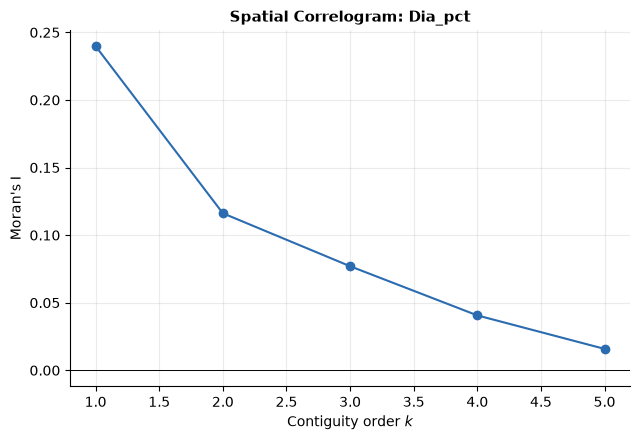

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(correlogram["order_k"], correlogram["Moran_I"], "o-", color=C["blue"])
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("Contiguity order $k$")
ax.set_ylabel("Moran's I")
ax.set_title("Spatial Correlogram: Dia_pct")
plt.tight_layout()
plt.show()

Autocorrelation is strongest at first order and decays toward zero as $k$ grows — consistent with a smoothly
varying regional process rather than long-range structure. `higher_order` on the Northeast counties (unlike a
distance-band or KNN graph) is well-defined even across the Nantucket island's own disconnection, since
`higher_order` never has to reach *across* a component boundary that does not exist in the first-order graph.

***
## 8. Transformations

`W.transform(conversion)` restandardises weights **in place**; the interpretation of every downstream statistic
depends on which one is active.

| Transform | Effect | Typical use |
|---|---|---|
| `'binary'` | $w_{ij} = 1$ for every neighbour | ICAR models (Part 5) need 0/1 adjacency |
| `'row'` (default for contiguity/KNN) | $w_{ij} = 1 / \lvert N_i\rvert$, rows sum to 1 | Moran's I as a *weighted average* of neighbour values; the standard choice |
| `'variance'` | $w_{ij} = w_{ij} / \sqrt{\sum_j w_{ij}}$ | Variance-stabilising; less common, seen in some regression contexts |

Row-standardisation is the default because it turns the spatial lag $Wz$ into an interpretable **average** of a
region's neighbours, and it is what makes Moran's I's regression-slope interpretation (Chapter 2.3) hold. Its
cost: row-standardised weights are **not symmetric** even when the underlying adjacency is (each row is scaled
by its own neighbour count), which matters for some estimators in Part 3.

In [15]:
w_demo = Queen(counties, transform="row")
print("row-standardised, row sums:", w_demo.sparse.sum(axis=1).A1[:6].round(4))
w_demo.transform("binary")
print("after .transform('binary'), row sums (= neighbour counts):", w_demo.sparse.sum(axis=1).A1[:6])
print("is_symmetric after binary transform:", w_demo.is_symmetric())
w_demo.transform("row")
print("is_symmetric after re-row-standardising:", w_demo.is_symmetric())

row-standardised, row sums: [1. 1. 1. 1. 1. 1.]
after .transform('binary'), row sums (= neighbour counts): [5. 6. 6. 3. 4. 6.]
is_symmetric after binary transform: True
is_symmetric after re-row-standardising: False


***
## 9. Islands and Disconnected Components

Section 3 already flagged one island in the Northeast Queen graph. Which county is it, and why?

In [16]:
wq = Queen(counties)
island_idx = wq.islands()
island_info = counties.iloc[island_idx][["FIPS", "STATE", "COUNTY"]]
print(f"island(s): {len(island_idx)}, components: {wq.n_components()}")
island_info

island(s): 1, components: 2


,FIPS,STATE,COUNTY
33,25019,Massachusetts,Nantucket County


**Nantucket County, MA** — an actual island with no land border to any other county — has zero Queen (or Rook)
neighbours by construction. This is not a data error to fix; it is a genuine topological fact that spatial
weights inherit directly from geography, and analysis has to make an explicit decision about it. Three options:

In [17]:
from spatialstats.weights import KNN

i = island_idx[0]

# Option A: drop the island entirely (row deleted, n reduced by one) — not shown here, just noted.

# Option B: KNN fallback for the island only — replace its (empty) contiguity row with its nearest neighbour(s)
wk1 = KNN(counties, k=1)
fallback_id = wk1.neighbors[i][0]
print("Option B (KNN fallback): nearest county to Nantucket by representative point =",
      counties.loc[fallback_id, "COUNTY"])

# Option C: manual link by centroid distance to the nearest other island (Dukes County / Martha's Vineyard)
coords = np.c_[counties.geometry.centroid.x, counties.geometry.centroid.y]
d = np.linalg.norm(coords - coords[i], axis=1)
d[i] = np.inf
manual_target = np.argmin(d)
print("Option C (manual link, by centroid): nearest county overall =",
      counties.iloc[manual_target]["COUNTY"], f"({d[manual_target]/1000:.1f} km)")

Option B (KNN fallback): nearest county to Nantucket by representative point = Barnstable County
Option C (manual link, by centroid): nearest county overall = Dukes County (49.8 km)


Options B and C do not agree (`representative_point` nearness picks the Cape Cod mainland, `centroid` nearness
picks Dukes County / Martha's Vineyard, itself another island) — a small illustration of Section 5.4's point
that coordinate choice is not cosmetic. Whichever fix is applied, **every downstream statistic that depends on
`w.n_components()` being 1** — several regression estimators in Part 3, the ICAR structure of Part 5 — is
affected, and the fix should be documented, not silently absorbed. Chapters 2.4–2.6 leave the island in place
(row-standardisation already handles it gracefully: `Moran`, `Moran_Local`, and friends give it `NaN`/`0`
contributions rather than crashing) and simply report `n=217, islands=1` alongside every result.

***
## 10. Spatial Lag by Hand

The **spatial lag** $Wz$ of a mean-centred attribute $z = y - \bar y$ is the building block of every statistic
in Chapters 2.4–2.5. On the 8×8 lattice, we compute it two ways — a direct loop over `w.neighbors`, and the
library's `w.lag()` — and confirm they agree to floating-point precision.

In [18]:
w_lat = Rook(lattice)
z = lattice[zcol].to_numpy()

lag_by_hand = np.zeros(len(z))
for idx in lattice.index:
    nbrs = w_lat.neighbors[idx]
    if nbrs:
        lag_by_hand[idx] = np.mean([z[w_lat.id_to_index[j]] for j in nbrs])  # row-standardised: mean of neighbours

lag_builtin = w_lat.lag(z)
max_diff = np.max(np.abs(lag_by_hand - lag_builtin))
print(f"z[:5]           = {z[:5].round(4)}")
print(f"lag by hand[:5] = {lag_by_hand[:5].round(4)}")
print(f"W.lag()[:5]     = {lag_builtin[:5].round(4)}")
print(f"max |difference| over all 64 cells: {max_diff:.2e}")

z[:5]           = [1.3443 1.8081 2.0399 1.338  0.3805]
lag by hand[:5] = [1.1812 1.437  1.4219 1.066  0.2497]
W.lag()[:5]     = [1.1812 1.437  1.4219 1.066  0.2497]
max |difference| over all 64 cells: 2.22e-16


Exact agreement (to machine precision), as expected: `W.lag(z)` for row-standardised weights *is* the vector of
neighbourhood means, computed with a sparse matrix–vector product instead of an explicit Python loop.

***
## 11. Interoperability with libpysal

`W.to_libpysal()` / `W.from_libpysal()` (requires the `[libpysal]` extra) convert to and from the PySAL
ecosystem's own weights class, so results can be cross-checked against the reference implementation (used again
in Chapter 2.6's exercises) or fed into PySAL tools this package does not implement.

In [19]:
try:
    lw = wq.to_libpysal()
    print(f"converted: libpysal W with n={lw.n}, mean neighbours={lw.mean_neighbors:.3f}")
    w_back = type(wq).__mro__[0].__bases__  # placeholder, not used
    from spatialstats.weights import W as SSW
    w_roundtrip = SSW.from_libpysal(lw)
    same_nbrs = all(set(wq.neighbors[i]) == set(w_roundtrip.neighbors[i]) for i in wq.id_order)
    print(f"round-tripped back to spatialstats.W: neighbour sets identical = {same_nbrs}")
except ImportError as e:
    print(f"libpysal not installed: {e}")

converted: libpysal W with n=217, mean neighbours=5.189
round-tripped back to spatialstats.W: neighbour sets identical = True


/home/zia207/Github/PySpatialStats/spatialstats/weights/w.py:225: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 33.
  return LibW(self.neighbors, self.weights, id_order=self.id_order)


***
## 12. A Sensitivity Preview: Six Weight Definitions, One Variable

Everything above was about the mechanics of `W`. Does the *choice* of `W` actually change a substantive
conclusion? A first look, with Chapter 2.6 returning to it properly (including permutation and FDR sensitivity):

In [20]:
band_thr = 100_000  # ~100 km, from Section 5.2
weight_defs = {
    "Queen": Queen(counties),
    "Rook": Rook(counties),
    "KNN(6)": KNN(counties, k=6),
    f"DistanceBand({band_thr//1000}km)": DistanceBand(counties, threshold=band_thr, binary=True),
    "Delaunay": Delaunay(counties),
    "Gabriel": Gabriel(counties),
}
rows = []
for name, w in weight_defs.items():
    m = Moran(counties["Dia_pct"], w, permutations=999, seed=1)
    rows.append({"weights": name, "mean_neighbours": round(w.cardinalities().mean(), 2),
                 "islands": len(w.islands()), "Moran_I": round(m.I, 4), "p_sim": m["p_sim"]})
sensitivity = pd.DataFrame(rows).sort_values("Moran_I", ascending=False).reset_index(drop=True)
sensitivity

,weights,mean_neighbours,islands,Moran_I,p_sim
0,Gabriel,4.50,0,0.2729,0.001
1,Delaunay,5.87,0,0.2481,0.001
2,Rook,5.15,1,0.2398,0.001
3,Queen,5.19,1,0.2398,0.001
4,KNN(6),6.00,0,0.2316,0.001
5,DistanceBand(100km),14.61,0,0.1161,0.001


Every definition agrees on the *qualitative* conclusion — positive, strongly significant autocorrelation
($p_\text{sim} = 0.001$, the floor for 999 permutations, throughout). But the *magnitude* varies by more than
double, from Gabriel's 0.273 down to the dense distance-band's 0.116: denser weight matrices (more neighbours
per region) systematically pull Moran's I toward zero, because averaging over a wider, less locally-specific
neighbourhood dilutes genuine local similarity with more distant, less related counties. **A reported Moran's I
is only interpretable together with the weights definition that produced it.**

***
## 13. Summary and Conclusions

This chapter built and compared every spatial weights definition used in the rest of Part 2.

### What we did

1. Inspected the anatomy of a `W` object: `neighbors`, `weights`, `sparse`, `cardinalities`, `islands`,
   `n_components`, `is_symmetric`, `summary()`.
2. Compared Queen and Rook contiguity: nearly identical on irregular counties, structurally different (8 vs. 4
   neighbours per interior cell) on a regular lattice.
3. Built distance-based weights (`KNN`, `DistanceBand`, `Kernel`) and found the smallest island-free
   `DistanceBand` threshold (≈99 km, mean 14.6 neighbours) — far denser than contiguity weights.
4. Confirmed `KNN`'s directed, asymmetric neighbour relation, and the difference between `representative_point`
   and `centroid` coordinates that every distance-based weight relies on.
5. Built the strictly nested Delaunay ⊇ Gabriel ⊇ Relative-Neighbourhood graph family and verified the nesting
   directly on the edge sets.
6. Computed a spatial correlogram with `higher_order`, showing autocorrelation decaying with neighbour order.
7. Distinguished the `'row'`, `'binary'`, and `'variance'` transforms and what each is used for downstream.
8. Identified Nantucket County as the Northeast graph's one true island, and compared three ways of handling it.
9. Hand-computed a spatial lag on the 8×8 lattice and matched `W.lag()` to machine precision.
10. Converted to and from `libpysal` for cross-checking, and previewed how much Moran's I moves across six
    weight definitions on the same variable.

### Practical takeaways

- There is no single "correct" `W`; every definition is a modelling choice with consequences for every
  downstream number (Section 12 quantifies this directly).
- Islands are not always errors — some are geography (Nantucket) — but every downstream method needs an
  explicit, documented decision about how to handle them.
- Row-standardisation is the practical default, but it breaks symmetry; know which estimators in Part 3 require
  a symmetric `W` instead.

### Next steps

**Chapter 2.3 (Visualisation and Exploratory Analysis)** takes the Queen `W` built here and turns it into a
choropleth, a Moran scatterplot, and a first visual read of *where* the clustering in `Dia_pct` sits.

***
## 14. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Anselin, L. (1988). *Spatial Econometrics: Methods and Models*. Kluwer Academic. | Chapter 3 remains the standard reference on spatial weights construction |
| Getis, A. & Aldstadt, J. (2004). Constructing the spatial weights matrix using a local statistic. *Geographical Analysis*, 36, 90–104. | Data-driven approaches to choosing weights, beyond fixed rules |
| Griffith, D. A. (1996). Some guidelines for specifying the geographic weights matrix contained in spatial statistical models. In *Practical Handbook of Spatial Statistics*. | Practical guidance on weights choice and its consequences |

### Key papers

| Paper | Contribution |
|---|---|
| Cliff, A. D. & Ord, J. K. (1973). *Spatial Autocorrelation*. Pion. | Early systematic treatment of contiguity-based weights |
| Matula, D. W. & Sokal, R. R. (1980). Properties of Gabriel graphs relevant to geographic variation research. *Geographical Analysis*, 12, 205–222. | The Gabriel graph, applied to spatial data |
| Toussaint, G. T. (1980). The relative neighbourhood graph of a finite planar set. *Pattern Recognition*, 12, 261–268. | Origin of the Relative Neighbourhood Graph |

### In this library

| Object | Role |
|---|---|
| `spatialstats.weights.W` | The weights container: `summary()`, `cardinalities()`, `islands()`, `n_components()`, `lag()`, `transform()`, `to_libpysal()`/`from_libpysal()` |
| `Queen`, `Rook` | Polygon contiguity weights |
| `KNN`, `DistanceBand`, `Kernel` | Distance-based weights |
| `Delaunay`, `Gabriel`, `RelativeNeighborhood` | Nested graph-based weights |
| `higher_order(w, k)` | k-th order neighbours, for correlograms |
| Chapter 2.4–2.5 | `esda.Moran`, `esda.Moran_Local` consume any `W` built here |
| Part 3 | Spatial regression, where the choice of `W` and its transform directly enters the likelihood |